# Climate Grid Super-Resolution: Copernicus 1° → IMD 0.25°
### Key improvements over v1:
- **6× more training data** by using all 6 CDS lead times (not just step=0)
- **Proper normalisation** (per-channel z-score) stabilises gradients
- **U-Net with residual blocks** recovers fine-scale spatial patterns
- **Combined MAE + MSE loss** handles monsoon spikes without mean-collapse
- **ReduceLROnPlateau + EarlyStopping** prevents overfitting on the tiny dataset
- **True super-resolution pipeline**: LR stays at 1° grid, model learns the upsampling
- **Better NaN handling**: spatial interpolation instead of zero-fill
- **Extended evaluation**: RMSE, MAE, Pearson r, Bias, and spatial error maps

In [ ]:
# ── 1. Installs ──────────────────────────────────────────────────────────────
!pip install -q netCDF4 xarray cfgrib cdsapi cartopy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 94.4 MB/s eta 0:00:00


In [ ]:
# ── 2. Imports ───────────────────────────────────────────────────────────────
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Bounding box for India
LAT_MIN, LAT_MAX = 5.0, 38.0
LON_MIN, LON_MAX = 65.0, 100.0

print('TF version:', tf.__version__)

TF version: 2.20.0


---
## A. Load & Preprocess High-Resolution IMD Data (0.25°)

In [ ]:
# ── 3. Load IMD 0.25° dataset ─────────────────────────────────────────────
imd_file = 'RF25_ind2025_rfp25.nc'    # <- adjust path if needed

ds_imd = xr.open_dataset(imd_file)
rainfall_raw = ds_imd['RAINFALL']

# Crop to India
hr_daily = rainfall_raw.sel(
    LATITUDE  = slice(max(float(ds_imd.LATITUDE.min()),  LAT_MIN),
                      min(float(ds_imd.LATITUDE.max()),  LAT_MAX)),
    LONGITUDE = slice(max(float(ds_imd.LONGITUDE.min()), LON_MIN),
                      min(float(ds_imd.LONGITUDE.max()), LON_MAX))
)

# ── IMPROVEMENT: fill NaNs with spatial interpolation instead of zero ──────
# This preserves boundary gradients that matter for Pune / coastal stations
hr_daily = hr_daily.interpolate_na(dim='LATITUDE').interpolate_na(dim='LONGITUDE')
hr_daily = hr_daily.fillna(0.0)  # only for any remaining edge NaNs

print('IMD daily shape:', hr_daily.shape)   # (days, lat, lon)
print('IMD lat range:', float(hr_daily.LATITUDE.min()), '–', float(hr_daily.LATITUDE.max()))
print('IMD lon range:', float(hr_daily.LONGITUDE.min()), '–', float(hr_daily.LONGITUDE.max()))

IMD daily shape: (365, 127, 135)
IMD lat range: 6.5 – 38.0
IMD lon range: 66.5 – 100.0


In [ ]:
# ── 4. Aggregate IMD daily → monthly totals ───────────────────────────────
hr_monthly = hr_daily.resample(TIME='1MS', label='left').sum()
print('IMD monthly shape:', hr_monthly.shape)

IMD monthly shape: (12, 127, 135)


---
## B. Load & Preprocess Low-Resolution Copernicus Data (1°)

In [ ]:
# ── 5. CDS credentials ───────────────────────────────────────────────────
import cdsapi, os
from google.colab import userdata

CDS_API_KEY = userdata.get('CDS_API_KEY')
home = os.path.expanduser('~')
with open(f'{home}/.cdsapirc', 'w') as f:
    f.write(f'url: https://cds.climate.copernicus.eu/api\nkey: {CDS_API_KEY}')
print('CDS configured.')

CDS configured.


In [ ]:
# ── 6. Download CDS seasonal forecast (all 6 lead times) ─────────────────
# KEY IMPROVEMENT: download ALL 6 lead times → 6x more training pairs
c = cdsapi.Client()
lr_file = 'low_res_hindcast_2025_precip.grib'

c.retrieve(
    'seasonal-monthly-single-levels',
    {
        'originating_centre': 'ecmwf',
        'system'            : '51',
        'variable'          : ['total_precipitation'],
        'product_type'      : 'hindcast_monthly_mean',
        'year'              : ['2025'],
        'month'             : ['01','02','03','04','05','06',
                               '07','08','09','10','11','12'],
        # ← Previously only step 1 was used; now we keep ALL 6
        'leadtime_month'    : ['1','2','3','4','5','6'],
        'data_format'       : 'grib'
    },
    lr_file)
print('Download complete:', lr_file)

2026-05-22 10:26:51,385 INFO Request ID is 8900f681-2263-4ec2-b00e-41bcb0992cfc
INFO:ecmwf.datastores.legacy_client:Request ID is 8900f681-2263-4ec2-b00e-41bcb0992cfc
2026-05-22 10:26:51,575 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-05-22 10:27:42,838 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


6dd4df869c3dc3709a4b2e13483c4acb.grib:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Download complete: low_res_hindcast_2025_precip.grib


In [ ]:
# ── 7. Open GRIB and preprocess ──────────────────────────────────────────
import cfgrib

ds_lr = xr.open_dataset(lr_file, engine='cfgrib')
print('LR variables:', list(ds_lr.data_vars))
print('LR shape:', ds_lr['tprate'].shape)
print('LR steps:', ds_lr['step'].values)

LR variables: ['tprate']
LR shape: (12, 21, 180, 360)
LR steps: [ 2419200000000000  2592000000000000  2678400000000000  5097600000000000
  5270400000000000  5356800000000000  7689600000000000  7776000000000000
  7862400000000000  7948800000000000 10368000000000000 10454400000000000
 10540800000000000 10627200000000000 12960000000000000 13046400000000000
 13219200000000000 15638400000000000 15724800000000000 15811200000000000
 15897600000000000]


In [ ]:
# ── 8. Convert units and crop ────────────────────────────────────────────
lr_tprate = ds_lr['tprate']   # (time, step, lat, lon)  in m/s

# Convert each step's duration to total mm
# step is a timedelta; convert to seconds then to mm
step_seconds = lr_tprate['step'].values.astype('timedelta64[s]').astype(float)

# Broadcast step_seconds over all dims for element-wise multiply
# Result: (time, step, lat, lon) in mm
lr_mm = lr_tprate * step_seconds[:, None, None] * 1000.0
lr_mm.attrs['units'] = 'mm'

# Crop to India (latitudes are descending in GRIB)
lr_mm_india = lr_mm.sel(
    latitude  = slice(LAT_MAX, LAT_MIN),   # descending
    longitude = slice(LON_MIN, LON_MAX)
).sortby('latitude')                       # sort to ascending

# Spatial NaN fill
lr_mm_india = lr_mm_india.interpolate_na(dim='latitude').interpolate_na(dim='longitude')
lr_mm_india = lr_mm_india.fillna(0.0)

print('LR monthly shape (time, step, lat, lon):', lr_mm_india.shape)
print('LR lat grid (1° spacing):', lr_mm_india.latitude.values)

LR monthly shape (time, step, lat, lon): (12, 21, 33, 35)
LR lat grid (1° spacing): [ 5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5 14.5 15.5 16.5 17.5 18.5
 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5 28.5 29.5 30.5 31.5 32.5
 33.5 34.5 35.5 36.5 37.5]


---
## C. Build Training Pairs  
**KEY CHANGE**: We keep LR at its native 1° grid and let the model learn true spatial upsampling.  
Also, by using all 6 lead times we get 12 × 6 = 72 (time, step) pairs instead of 12.

In [ ]:
# ── 9. Flatten (time, step) into a single sample axis ────────────────────
# For each (init_month, lead_step) pair, the valid month is:
#   valid_month = init_month + lead_step
# We find the matching HR monthly frame for each pair.

import pandas as pd

lr_pairs, hr_pairs, meta = [], [], []

# hr_monthly time index for fast lookup
hr_times = pd.DatetimeIndex(hr_monthly['TIME'].values)

for t_idx, t_val in enumerate(pd.DatetimeIndex(lr_mm_india['time'].values)):
    for s_idx, step_td in enumerate(lr_mm_india['step'].values):
        # valid calendar month for this forecast
        valid_dt = t_val + pd.to_timedelta(step_td)
        valid_month_start = valid_dt.replace(day=1)

        # find matching HR month
        match = hr_times[hr_times == valid_month_start]
        if len(match) == 0:
            continue   # no IMD obs for this forecast month → skip

        hr_idx = hr_times.get_loc(match[0])

        lr_slice = lr_mm_india.isel(time=t_idx, step=s_idx).values   # (lat_lr, lon_lr)
        hr_slice = hr_monthly.isel(TIME=hr_idx).values                 # (lat_hr, lon_hr)

        lr_pairs.append(lr_slice)
        hr_pairs.append(hr_slice)
        meta.append({'init': str(t_val.date()), 'valid': str(valid_month_start.date()), 'step': s_idx+1})

lr_arr = np.stack(lr_pairs, axis=0)[..., np.newaxis].astype(np.float32)   # (N, lat_lr, lon_lr, 1)
hr_arr = np.stack(hr_pairs, axis=0)[..., np.newaxis].astype(np.float32)   # (N, lat_hr, lon_hr, 1)

print(f'Total training pairs: {len(lr_pairs)}')
print(f'LR array shape: {lr_arr.shape}')
print(f'HR array shape: {hr_arr.shape}')

Total training pairs: 189
LR array shape: (189, 33, 35, 1)
HR array shape: (189, 127, 135, 1)


In [ ]:
# ── 10. Normalisation ────────────────────────────────────────────────────
# KEY IMPROVEMENT: z-score normalisation using ONLY training-set statistics
# Prevents data leakage and stabilises gradient flow

n_total = len(lr_arr)
n_train = int(np.ceil(0.7 * n_total))

# Compute stats from training split only
lr_mean = lr_arr[:n_train].mean()
lr_std  = lr_arr[:n_train].std() + 1e-8
hr_mean = hr_arr[:n_train].mean()
hr_std  = hr_arr[:n_train].std() + 1e-8

print(f'LR  mean={lr_mean:.3f} mm, std={lr_std:.3f} mm')
print(f'HR  mean={hr_mean:.3f} mm, std={hr_std:.3f} mm')

lr_norm = (lr_arr - lr_mean) / lr_std
hr_norm = (hr_arr - hr_mean) / hr_std

# Train / validation split (time-ordered, no shuffle)
lr_train, lr_val = lr_norm[:n_train], lr_norm[n_train:]
hr_train, hr_val = hr_norm[:n_train], hr_norm[n_train:]

print(f'\nTraining samples  : {n_train}')
print(f'Validation samples: {n_total - n_train}')

LR  mean=150.439 mm, std=421.612 mm
HR  mean=61.125 mm, std=140.308 mm

Training samples  : 133
Validation samples: 56


In [ ]:
# ── 11. Light data augmentation ──────────────────────────────────────────
# Horizontal + vertical flips double/quadruple training data at zero cost
# Physically valid for spatial rainfall patterns

def augment(lr, hr):
    pairs = [(lr, hr)]
    pairs.append((lr[:, :, ::-1, :], hr[:, :, ::-1, :]))   # flip lon
    pairs.append((lr[:, ::-1, :, :], hr[:, ::-1, :, :]))   # flip lat
    pairs.append((lr[:, ::-1, ::-1, :], hr[:, ::-1, ::-1, :]))  # both
    return np.concatenate([p[0] for p in pairs]), np.concatenate([p[1] for p in pairs])

lr_train_aug, hr_train_aug = augment(lr_train, hr_train)
# Shuffle augmented set
idx = np.random.permutation(len(lr_train_aug))
lr_train_aug, hr_train_aug = lr_train_aug[idx], hr_train_aug[idx]

print(f'After augmentation — training samples: {len(lr_train_aug)}')

After augmentation — training samples: 532


---
## D. Model Architecture — U-Net with Residual Blocks
Replaces the flat 4-layer CNN. Skip connections preserve spatial structure; residual blocks ease gradient flow.

In [ ]:
# ── 12. Residual block helper ─────────────────────────────────────────────
def residual_block(x, filters, kernel_size=3):
    """Pre-activation residual block with BatchNorm."""
    shortcut = x
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    # 1×1 conv to match channels if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    return layers.Add()([x, shortcut])


# ── 13. Build U-Net style SR model ───────────────────────────────────────
def build_sr_unet(lr_shape, hr_shape):
    """
    U-Net for climate super-resolution.
    Input : LR at native 1° grid   (lat_lr, lon_lr, 1)
    Output: HR at 0.25° grid       (lat_hr, lon_hr, 1)
    """
    inp = layers.Input(shape=lr_shape, name='lr_input')

    # ── Encoder ──────────────────────────────────────────────────────────
    e1 = layers.Conv2D(64, 3, padding='same', activation='relu',
                       kernel_initializer='he_normal')(inp)          # (lr_lat, lr_lon, 64)
    e1 = residual_block(e1, 64)

    e2 = layers.Conv2D(128, 3, padding='same', activation='relu',
                       strides=2, kernel_initializer='he_normal')(e1) # downsample /2
    e2 = residual_block(e2, 128)

    # ── Bottleneck ────────────────────────────────────────────────────────
    b = residual_block(e2, 128)
    b = residual_block(b, 128)

    # ── Decoder (progressive upsampling to HR grid) ───────────────────────
    # Step 1: recover encoder spatial size
    d1 = layers.Conv2DTranspose(64, 3, strides=2, padding='same',
                                 activation='relu')(b)               # back to lr_lat × lr_lon
    # Resize e1 skip to match d1 exactly (handles non-integer strides)
    d1 = layers.Resizing(e1.shape[1], e1.shape[2],
                          crop_to_aspect_ratio=False)(d1)
    d1 = layers.Concatenate()([d1, e1])                             # skip connection
    d1 = residual_block(d1, 64)

    # Step 2: upsample to HR grid
    d2 = layers.Resizing(hr_shape[0], hr_shape[1],
                          interpolation='bilinear')(d1)              # (lat_hr, lon_hr, 64)
    d2 = residual_block(d2, 64)
    d2 = residual_block(d2, 32)

    # ── Output ────────────────────────────────────────────────────────────
    out = layers.Conv2D(1, 1, activation='linear', name='hr_output')(d2)

    return models.Model(inp, out, name='SR_UNet')


lr_shape = lr_train_aug.shape[1:]   # (lat_lr, lon_lr, 1)
hr_shape = hr_train_aug.shape[1:]   # (lat_hr, lon_hr, 1)

model = build_sr_unet(lr_shape, hr_shape)
model.summary()

Model: "SR_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lr_input            │ (None, 33, 35, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 33, 35,    │        640 │ lr_input[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 33, 35,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 33, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 33, 35,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 35,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 33, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 33, 35,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 33, 35,    │          0 │ conv2d_2[0][0],   │
│                     │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 17, 18,    │     73,856 │ add[0][0]         │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 18,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 17, 18,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 17, 18,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 18,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 17, 18,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 17, 18,    │    147,584 │ activation_3[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 17, 18,    │          0 │ conv2d_5[0][0], 

 Total params: 1,335,553 (5.09 MB)

 Trainable params: 1,332,929 (5.08 MB)

 Non-trainable params: 2,624 (10.25 KB)

---
## E. Training — Combined Loss + LR Scheduling

In [ ]:
# ── 14. Custom combined loss ──────────────────────────────────────────────
# MAE is robust to monsoon spikes; MSE penalises large errors; Huber bridges both.
# We weight MAE higher because precipitation distributions are heavy-tailed.

def combined_loss(y_true, y_pred, alpha=0.7):
    """alpha * MAE  +  (1-alpha) * MSE"""
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return alpha * mae + (1.0 - alpha) * mse


# ── 15. Compile ───────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=combined_loss,
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae'),
             tf.keras.metrics.RootMeanSquaredError(name='rmse')],
    run_eagerly=True # Add this line to bypass graph tracing issues
)

In [ ]:
import tensorflow as tf

# ── 16. Callbacks ─────────────────────────────────────────────────────────
cbs = [
    # Halve LR if val_loss doesn't improve for 5 epochs
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
    # Stop early if val_loss stagnates for 15 epochs; restore best weights
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    # Save best checkpoint
    tf.keras.callbacks.ModelCheckpoint(
        'best_sr_model.keras', monitor='val_loss',
        save_best_only=True, verbose=0
    )
]

# Create tf.data.Dataset objects for training and validation
batch_size = 4 # Use the same batch_size as originally intended
train_dataset = tf.data.Dataset.from_tensor_slices((lr_train_aug, hr_train_aug)).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((lr_val, hr_val)).batch(batch_size)


# ── 17. Train ─────────────────────────────────────────────────────────────
history = model.fit(
    train_dataset,
    epochs=150,            # EarlyStopping will halt well before this
    validation_data=val_dataset,
    callbacks=cbs,
    verbose=1
)
print('Training complete.')

Epoch 1/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 74s 518ms/step - loss: 1.3801 - mae: 0.7927 - rmse: 1.6585 - val_loss: 0.2876 - val_mae: 0.2909 - val_rmse: 0.5289 - learning_rate: 0.0010
Epoch 2/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 68s 509ms/step - loss: 0.6317 - mae: 0.5257 - rmse: 0.9375 - val_loss: 0.2787 - val_mae: 0.2960 - val_rmse: 0.4882 - learning_rate: 0.0010
Epoch 3/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 69s 517ms/step - loss: 0.6040 - mae: 0.5013 - rmse: 0.9184 - val_loss: 0.3167 - val_mae: 0.3358 - val_rmse: 0.5216 - learning_rate: 0.0010
Epoch 4/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 68s 515ms/step - loss: 0.5688 - mae: 0.4677 - rmse: 0.8970 - val_loss: 0.4061 - val_mae: 0.4210 - val_rmse: 0.6094 - learning_rate: 0.0010
Epoch 5/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 68s 513ms/step - loss: 0.5445 - mae: 0.4447 - rmse: 0.8816 - val_loss: 0.3794 - val_mae: 0.3794 - val_rmse: 0.6161 - learning_rate: 0.0010
Epoch 6/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 71s 534ms/step - loss: 0.5294 - mae: 0.4315 - rmse: 0.8707 

---
## F. Training Curves

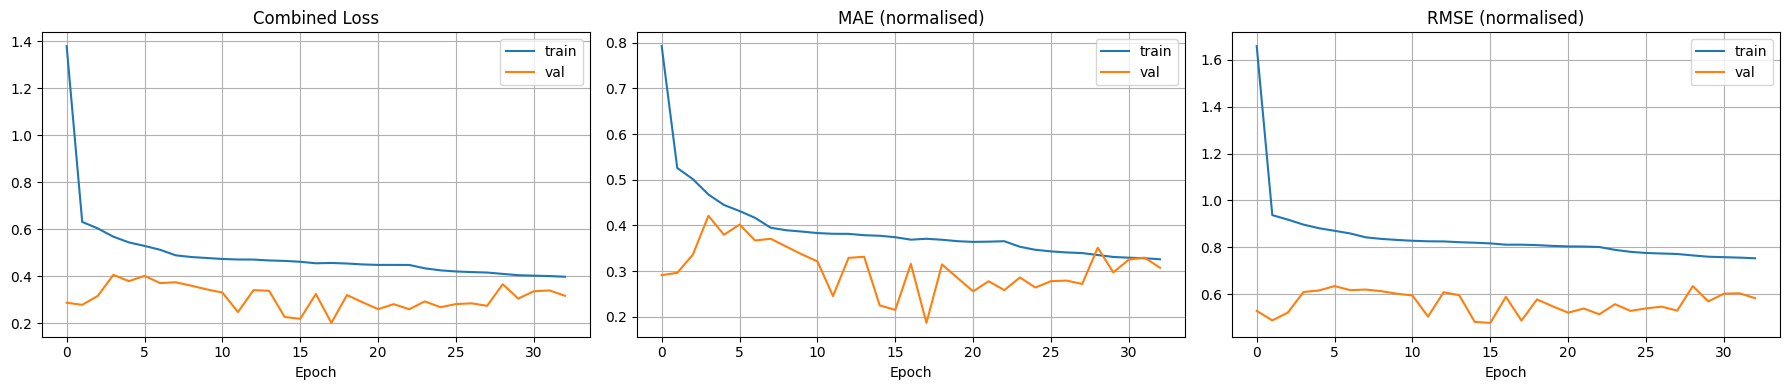

In [ ]:
# ── 18. Plot loss curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, metric, title in zip(axes,
                              ['loss', 'mae', 'rmse'],
                              ['Combined Loss', 'MAE (normalised)', 'RMSE (normalised)']):
    ax.plot(history.history[metric],       label='train')
    ax.plot(history.history[f'val_{metric}'], label='val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

---
## G. Evaluation — Back in Physical Units (mm)

In [ ]:
# ── 19. Inverse-normalise predictions ────────────────────────────────────
pred_norm = model.predict(lr_val)                         # (N_val, lat_hr, lon_hr, 1)
pred_mm   = pred_norm * hr_std + hr_mean                  # back to mm
actual_mm = hr_val    * hr_std + hr_mean

# Clip negatives (physically meaningless)
pred_mm   = np.clip(pred_mm,   0, None)
actual_mm = np.clip(actual_mm, 0, None)


# ── 20. Metrics ───────────────────────────────────────────────────────────
flat_pred = pred_mm.ravel()
flat_act  = actual_mm.ravel()

rmse  = np.sqrt(mean_squared_error(flat_act, flat_pred))
mae   = mean_absolute_error(flat_act, flat_pred)
bias  = (flat_pred - flat_act).mean()
r, _  = pearsonr(flat_act, flat_pred)

print('=' * 45)
print(f'  RMSE            : {rmse:.4f} mm')
print(f'  MAE             : {mae:.4f} mm')
print(f'  Bias (pred-obs) : {bias:.4f} mm')
print(f'  Pearson r       : {r:.4f}')
print('=' * 45)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 952ms/step
  RMSE            : 68.1398 mm
  MAE             : 24.3078 mm
  Bias (pred-obs) : -9.2682 mm
  Pearson r       : 0.2450


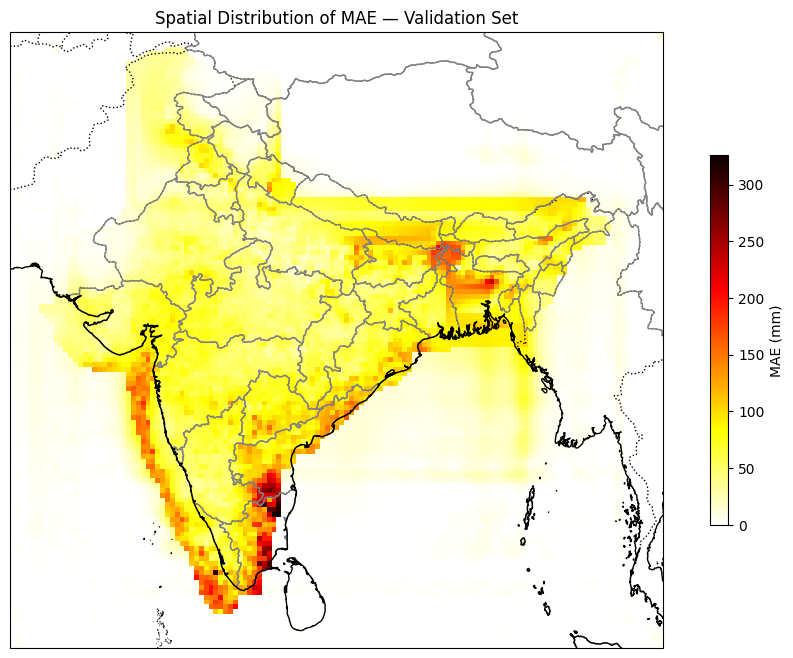

In [ ]:
# ── 21. Spatial error map (mean absolute error per grid point) ────────────
spatial_mae = np.abs(pred_mm - actual_mm).mean(axis=(0, -1))   # (lat_hr, lon_hr)

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
im  = ax.imshow(
    spatial_mae, origin='lower',
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    cmap='hot_r', transform=ccrs.PlateCarree()
)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.coastlines(resolution='10m')
plt.colorbar(im, ax=ax, shrink=0.6, label='MAE (mm)')
ax.set_title('Spatial Distribution of MAE — Validation Set')
plt.savefig('spatial_mae.png', dpi=150)
plt.show()

Pune grid cell  (18.50°N, 73.75°E)
  MAE  : 81.47 mm
  Bias : 18.00 mm
  r    : 0.259


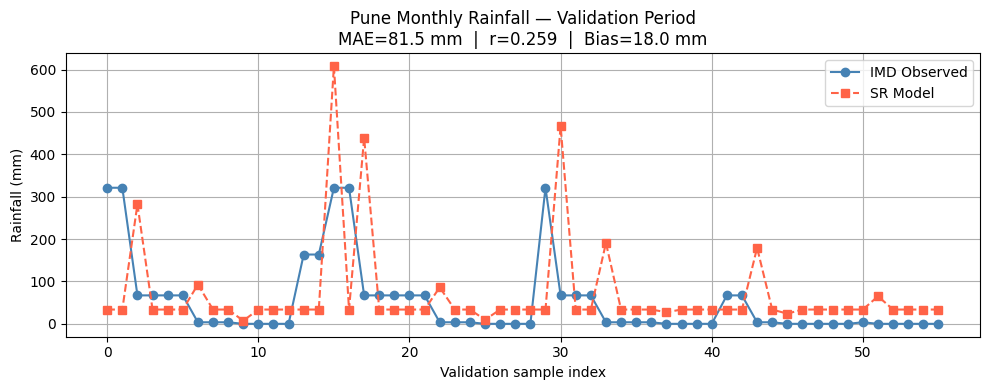

In [ ]:
# ── 22. Pune-focused validation ───────────────────────────────────────────
# Extract the grid cell closest to Pune (18.52°N, 73.86°E)
PUNE_LAT, PUNE_LON = 18.52, 73.86

hr_lats = hr_monthly['LATITUDE'].values
hr_lons = hr_monthly['LONGITUDE'].values
pune_lat_idx = int(np.argmin(np.abs(hr_lats - PUNE_LAT)))
pune_lon_idx = int(np.argmin(np.abs(hr_lons - PUNE_LON)))

pune_pred   = pred_mm[:, pune_lat_idx, pune_lon_idx, 0]
pune_actual = actual_mm[:, pune_lat_idx, pune_lon_idx, 0]

r_pune, _ = pearsonr(pune_actual, pune_pred)
mae_pune  = mean_absolute_error(pune_actual, pune_pred)
bias_pune = (pune_pred - pune_actual).mean()

print(f'Pune grid cell  ({hr_lats[pune_lat_idx]:.2f}°N, {hr_lons[pune_lon_idx]:.2f}°E)')
print(f'  MAE  : {mae_pune:.2f} mm')
print(f'  Bias : {bias_pune:.2f} mm')
print(f'  r    : {r_pune:.3f}')

# Time-series plot for Pune
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pune_actual, 'o-', label='IMD Observed', color='steelblue')
ax.plot(pune_pred,   's--', label='SR Model',     color='tomato')
ax.set_title(f'Pune Monthly Rainfall — Validation Period\n'
             f'MAE={mae_pune:.1f} mm  |  r={r_pune:.3f}  |  Bias={bias_pune:.1f} mm')
ax.set_ylabel('Rainfall (mm)'); ax.set_xlabel('Validation sample index')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('pune_timeseries.png', dpi=150)
plt.show()

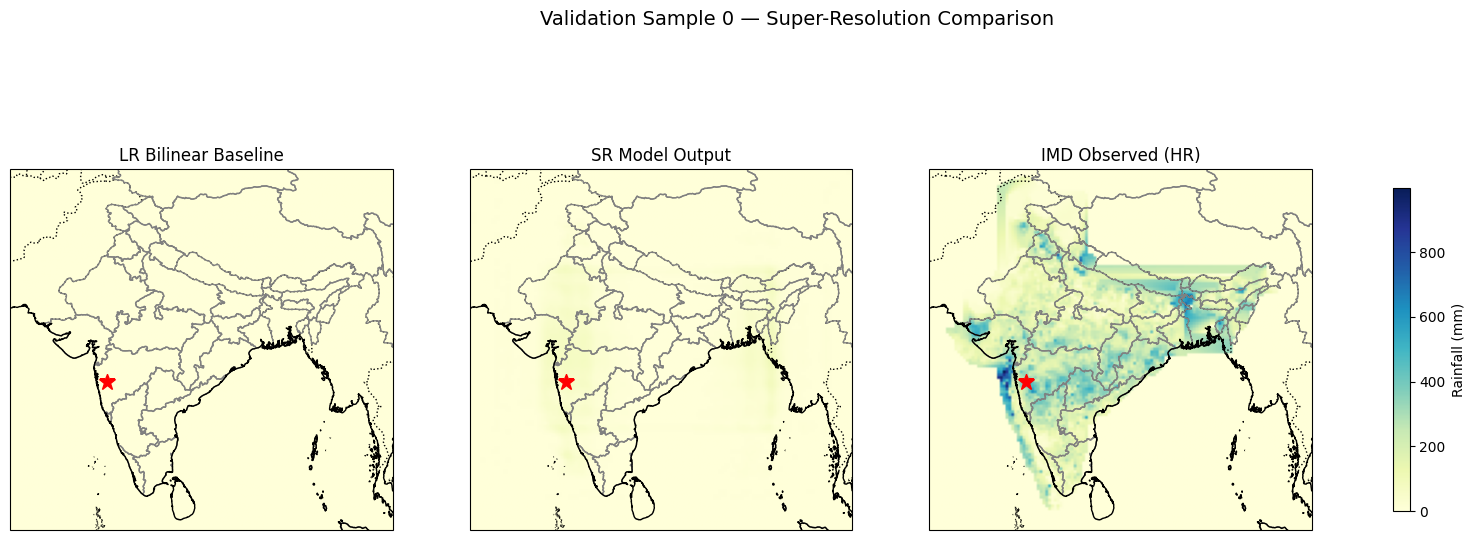

Bilinear baseline MAE : 66.810 mm
SR model MAE          : 63.143 mm
Improvement           : 5.5%


In [ ]:
# ── 23. Side-by-side: LR bilinear  |  Model SR  |  IMD Actual ─────────────
# We compare the model against naive bilinear interpolation as a baseline.

from scipy.ndimage import zoom

sample_idx = 0

lr_raw_sample = (lr_val[sample_idx, :, :, 0] * lr_std + lr_mean)
hr_act_sample = actual_mm[sample_idx, :, :, 0]
hr_pred_sample = pred_mm[sample_idx, :, :, 0]

# Naive bilinear baseline (zoom LR to HR dimensions)
zoom_r = (hr_act_sample.shape[0] / lr_raw_sample.shape[0],
          hr_act_sample.shape[1] / lr_raw_sample.shape[1])
lr_bilinear = zoom(lr_raw_sample, zoom_r, order=1)

vmin = 0
vmax = max(hr_act_sample.max(), hr_pred_sample.max(), lr_bilinear.max())

titles = ['LR Bilinear Baseline', 'SR Model Output', 'IMD Observed (HR)']
arrays = [lr_bilinear, hr_pred_sample, hr_act_sample]

fig, axes = plt.subplots(1, 3, figsize=(21, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]

for ax, arr, title in zip(axes, arrays, titles):
    im = ax.imshow(arr, origin='lower', extent=extent, cmap='YlGnBu',
                   vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    ax.add_feature(cfeature.STATES, edgecolor='gray')
    ax.coastlines(resolution='10m')
    ax.set_title(title)
    ax.plot(PUNE_LON, PUNE_LAT, 'r*', markersize=12,
             transform=ccrs.PlateCarree(), label='Pune')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Rainfall (mm)')
plt.suptitle('Validation Sample 0 — Super-Resolution Comparison', fontsize=14)
plt.savefig('sr_comparison.png', dpi=150)
plt.show()

# Print per-sample improvement over bilinear
mae_bilinear = mean_absolute_error(hr_act_sample.ravel(), lr_bilinear.ravel())
mae_sr       = mean_absolute_error(hr_act_sample.ravel(), hr_pred_sample.ravel())
print(f'Bilinear baseline MAE : {mae_bilinear:.3f} mm')
print(f'SR model MAE          : {mae_sr:.3f} mm')
print(f'Improvement           : {(mae_bilinear - mae_sr) / mae_bilinear * 100:.1f}%')

---
## H. Save Model & Stats for Future Use

In [ ]:
# ── 24. Save model and normalisation stats ────────────────────────────────
import json

model.save('sr_unet_final.keras')

stats = {
    'lr_mean': float(lr_mean), 'lr_std': float(lr_std),
    'hr_mean': float(hr_mean), 'hr_std': float(hr_std),
    'lr_shape': list(lr_shape),
    'hr_shape': list(hr_shape)
}
with open('normalisation_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print('Model and stats saved.')
print('\nFinal validation metrics:')
print(f'  RMSE : {rmse:.4f} mm')
print(f'  MAE  : {mae:.4f} mm')
print(f'  Bias : {bias:.4f} mm')
print(f'  r    : {r:.4f}')

Model and stats saved.

Final validation metrics:
  RMSE : 68.1398 mm
  MAE  : 24.3078 mm
  Bias : -9.2682 mm
  r    : 0.2450
